In [1]:
using Pkg

ROOT = abspath(joinpath(@__DIR__, ".."))
Pkg.activate(ROOT)

using PulsePropagation
using FFTW
using LinearAlgebra
using PyPlot
using DelimitedFiles

  Activating project at `~/FastDifferentiableMMNLO`


# Squeezing by spectral filtering in GIF625

This notebook sets up a small example of the type of system we measured: spatio-spectrally filtered pulses going through GRIN fiber. Note that here I consider a one meter example for faster simulations. A 20 m case should be executed on a GPU instead. This notebook with the shorter fiber should alllow us to already look at wavelength dependence, power dependence, and some more limited length dependence.

Cell below sets the simulation domain.

In [2]:
c_light = 2.9979e-4; #m/ps
Nt = 2^12;
time_window = 10;
λ0 = 1550e-9; #m
f0 = c_light / λ0; #THz

dofs = degrees_of_freedom(:time, :space, :polarization)
grid = TimeGrid(Nt, time_window)
domain = MMGNLSEDomain(dofs; time_grid = grid)

t, Ω = time_axis(grid), frequency_axis(grid); #time in ps, Ω in 1/ps. Ω is frequency offset from center.
f = f0 .+ Ω/(2*π); #THz
λ = c_light ./ (f);
λ_nm = 1e9 * λ;

The next cells setup the material, fiber, and initial pulse. You can consult the manual for usage info (e.g., arguments of functions).

In [3]:
material = Silica(); # Silica with standard anisotropic Raman response averaged over polarization

num_modes = 10;
core_radius = 62.5e-6 / 2;
NA = 0.275;
fiber = GRIN(λ0, core_radius, NA);
L_fiber = 1;

properties = compute_fiber_properties(fiber, material, num_modes, polarization = :linear, mode_basis = :LP, beta_order = 5);

## This below compresses the tensor to make the calculations much faster with little accuracy change (~20x for 10 modes)
S_cp = cp_compress(properties.S; error = 1e-3);

parameters = MMGNLSEParameters(domain; length = L_fiber, beta = properties.beta, S = S_cp, raman = properties.raman, n2 = properties.n2, omega0 = 2*π*f0)

MMGNLSEParameters{MMGNLSEDomain{TimeGrid{Float64}}, Float64, Array{Int64, 4}, Array{Int64, 4}, TaylorBeta{Float64, 2}, MMGNLSECPDecomposition{Float64, ComplexF64}, Float64, Float64, AnisotropicRaman{Float64}}(MMGNLSEDomain{TimeGrid{Float64}}(DegreesOfFreedom(:time, :space, :polarization), TimeGrid{Float64}(4096, 0.00244140625)), 1.0, [0;;;;], [0;;;;], TaylorBeta{Float64, 2}([5.847495001399134e6 5.841391378399655e6 … 5.829164959421696e6 5.829164959421696e6; 4878.763942245547 4878.836612505644 … 4878.998457263862 4878.998457263862; … ; -4.966560219950897e-7 -4.989883301338437e-7 … -5.039095226711715e-7 -5.039095226711715e-7; 2.341566545293194e-9 2.3565992573335836e-9 … 2.3791369035413277e-9 2.3791369035413277e-9]), MMGNLSECPDecomposition{Float64, ComplexF64}([1.310904489634547e10, 2.172830688856531e10, 2.110021481648813e10, 6.0932401495450615e10, 2.7505329452305527e10, 5.035835791696129e10, 7.540699135958606e10, 1.2882956592142954e10, 7.474223157471252e10, 1.841366856291153e10  …  1.3729

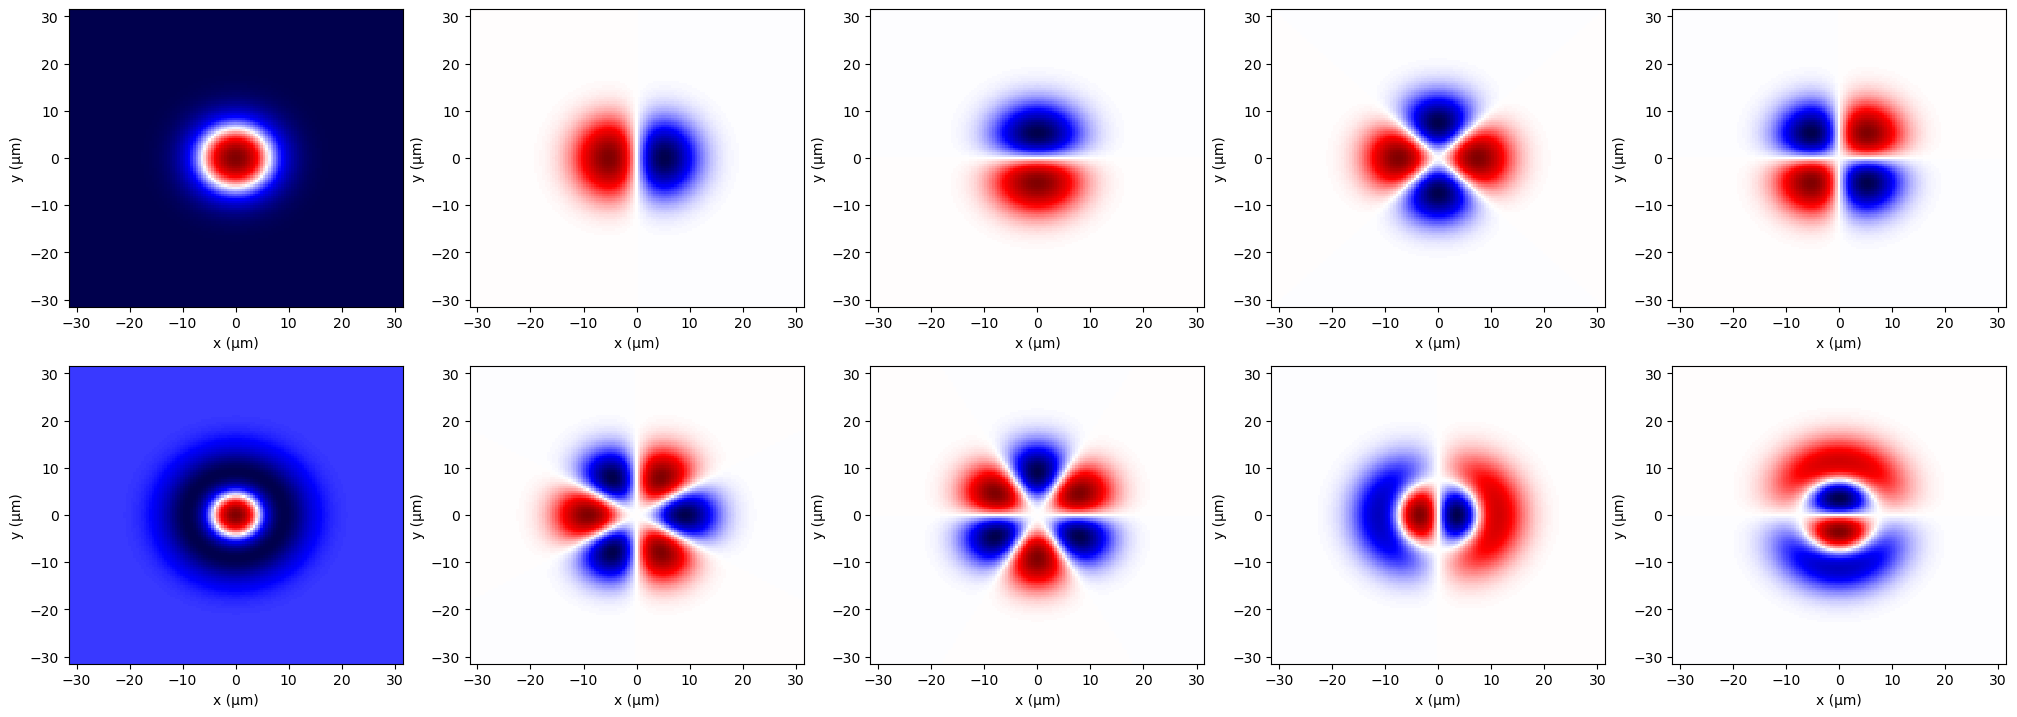

In [4]:
x = properties.modes.x;
y = properties.modes.y;
modes = properties.modes.fields;

figure(figsize=(25,8.5))

for ii = 1:10
    subplot(2,5,ii)
    pcolormesh(x*1e6,y*1e6,modes[:,:,ii],cmap="seismic")
    xlabel("x (μm)")
    ylabel("y (μm)")
end
display(gcf())

In [5]:
#LP01 excitation

peak_power = 6000;
pulse_fwhm = 0.2;

coefficient_vector = zeros(num_modes,2); ## num_modes in mode axis, 2 in polarization axis
coefficient_vector[1,1] = 1.0;

initial_field = gaussian_pulse(
    domain, num_modes;
    peak_power=peak_power, # W
    fwhm=pulse_fwhm,
    coefficients = coefficient_vector
);

In [7]:
dz_forward = 0.01;
solution = solve_mmgnlse(initial_field, parameters, dz_forward)

MMGNLSESolution{Float64, Array{ComplexF64, 4}, MMGNLSEParameters{MMGNLSEDomain{TimeGrid{Float64}}, Float64, Array{Int64, 4}, Array{Int64, 4}, TaylorBeta{Float64, 2}, MMGNLSECPDecomposition{Float64, ComplexF64}, Float64, Float64, AnisotropicRaman{Float64}}, Array{ComplexF64, 3}, RK4IP, @NamedTuple{integration_z::Vector{Float64}, core::@NamedTuple{omega::Vector{Float64}, beta_operator::Array{ComplexF64, 3}, nonlinear_prefactor::Array{ComplexF64, 3}, nonlinear_active::Bool, raman::@NamedTuple{ha::Vector{ComplexF64}, hb::Vector{ComplexF64}, fraction::Float64}}}}([0.0, 1.0], ComplexF64[0.0 + 0.0im 0.0 + 0.0im … 0.0 + 0.0im 0.0 + 0.0im; 0.0 + 0.0im 0.0 + 0.0im … 0.0 + 0.0im 0.0 + 0.0im; … ; 0.0 + 0.0im 0.0 + 0.0im … 0.0 + 0.0im 0.0 + 0.0im; 0.0 + 0.0im 0.0 + 0.0im … 0.0 + 0.0im 0.0 + 0.0im;;; 0.0 + 0.0im 0.0 + 0.0im … 0.0 + 0.0im 0.0 + 0.0im; 0.0 + 0.0im 0.0 + 0.0im … 0.0 + 0.0im 0.0 + 0.0im; … ; 0.0 + 0.0im 0.0 + 0.0im … 0.0 + 0.0im 0.0 + 0.0im; 0.0 + 0.0im 0.0 + 0.0im … 0.0 + 0.0im 0.0 + 0

Visualizing the solution in spectrum and space. The spectrum seems to redshift, which could be consistent with the behavior we see in the experiment of two lumps merging into the redder lump.

In [152]:
Aω = get_spectral_field(solution;z=:all);
Ixy = get_spectrally_summed_spatial_intensity(solution, properties);

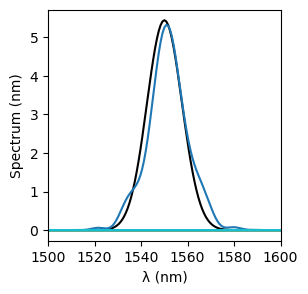

In [153]:
figure(figsize=(3,3))
plot(λ_nm, abs2.(Aω[:,:,1,1]), color="k") # initial spectrum
plot(λ_nm, abs2.(Aω[:,:,1,end])) # final spectrum
xlim(1500,1600)
xlabel("λ (nm)")
ylabel("Spectrum (nm)")
display(gcf())

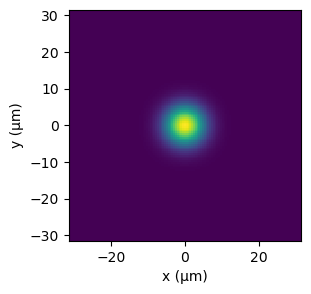

In [154]:
figure(figsize=(3,3))
pcolormesh(x * 1e6,y * 1e6,Ixy)
xlabel("x (μm)")
ylabel("y (μm)")
display(gcf())

The following calculations look at noise with spectral filtering.

In [155]:
λ_low = 1540;
λ_high = 1560;
ind_low_tmp = argmin(abs.(λ_nm .- λ_low));
ind_high_tmp = argmin(abs.(λ_nm .- λ_high));

ind_low = minimum([ind_low_tmp, ind_high_tmp]); #argh!
ind_high = maximum([ind_low_tmp, ind_high_tmp]);

bandpass_filter = zeros(Nt,num_modes,2);
bandpass_filter[ind_low:ind_high,1,:] .= 1.0; # polarization-insensitive bandpass

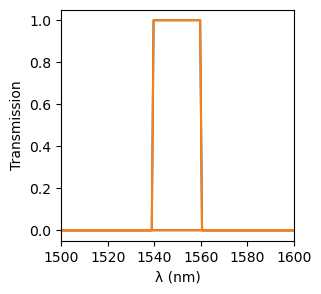

In [156]:
figure(figsize=(3,3))
plot(λ_nm, bandpass_filter[:,1,:])
xlim(1500,1600)
xlabel("λ (nm)")
ylabel("Transmission")
display(gcf())

In [157]:
obs = SpectralPhotonNumber(filter=bandpass_filter);
n_out = value(obs,solution);
lambda_L = terminal_condition(obs,solution); ## initial adjoint field

In [158]:
dz_adjoint = dz_forward;
adjoint = solve_adjoint(lambda_L, parameters, dz_adjoint; forward_solution = solution, units = :photon)

MMGNLSEAdjointSolution{Float64, Array{ComplexF64, 4}, MMGNLSEParameters{MMGNLSEDomain{TimeGrid{Float64}}, Float64, Array{Int64, 4}, Array{Int64, 4}, TaylorBeta{Float64, 2}, MMGNLSECPDecomposition{Float64, ComplexF64}, Float64, Float64, AnisotropicRaman{Float64}}, @NamedTuple{forward_solution::MMGNLSESolution{Float64, Array{ComplexF64, 4}, MMGNLSEParameters{MMGNLSEDomain{TimeGrid{Float64}}, Float64, Array{Int64, 4}, Array{Int64, 4}, TaylorBeta{Float64, 2}, MMGNLSECPDecomposition{Float64, ComplexF64}, Float64, Float64, AnisotropicRaman{Float64}}, Array{ComplexF64, 3}, RK4IP, @NamedTuple{integration_z::Vector{Float64}, core::@NamedTuple{omega::Vector{Float64}, beta_operator::Array{ComplexF64, 3}, nonlinear_prefactor::Array{ComplexF64, 3}, nonlinear_active::Bool, raman::@NamedTuple{ha::Vector{ComplexF64}, hb::Vector{ComplexF64}, fraction::Float64}}}}, integration_z::Vector{Float64}, frame::Symbol, core::@NamedTuple{omega::Vector{Float64}, beta_operator::Array{ComplexF64, 3}, nonlinear_pref

In [159]:
spectral_sensitivity = get_spectral_field(adjoint; units = :photon);
photon_number_var = sum(abs2.(spectral_sensitivity));
fano = sum(abs2.(spectral_sensitivity)) / n_out;
println("The fano factor is $(10log10(fano)) dB.")

The fano factor is -4.68950941096657 dB.


The above gives an example of a calculation for a single power. Now we'll do this in a loop over powers. Note that this loop relies on lines before to run, so if you want it to be self-contained, you need to define everything else.

In [165]:
peak_power_list = [0.5:0.5:10;]*1e3;
n_out_list = zeros(length(peak_power_list));
fano_list = zeros(length(peak_power_list));

for ii = 1:length(peak_power_list)

    peak_power = peak_power_list[ii];
    
    initial_field = gaussian_pulse(
    domain, num_modes;
    peak_power=peak_power, # W
    fwhm=pulse_fwhm,
    coefficients = coefficient_vector
    );

    solution = solve_mmgnlse(initial_field, parameters, dz_forward)

    n_out = value(obs,solution);
    n_out_list[ii] = n_out;

    lambda_L = terminal_condition(obs,solution); ## initial adjoint field
    adjoint = solve_adjoint(lambda_L, parameters, dz_adjoint; forward_solution = solution, units = :photon)
    
    spectral_sensitivity = get_spectral_field(adjoint; units = :photon);
    photon_number_var = sum(abs2.(spectral_sensitivity));
    fano = sum(abs2.(spectral_sensitivity)) / n_out;
    fano_list[ii] = fano;

end
    

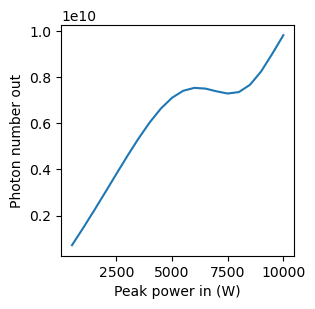

In [208]:
figure(figsize=(3,3))
plot(peak_power_list, n_out_list,"-")
xlabel("Peak power in (W)")
ylabel("Photon number out")
display(gcf())

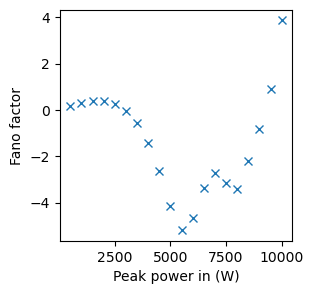

In [184]:
figure(figsize=(3,3))
plot(peak_power_list, 10log10.(fano_list), "x")
xlabel("Peak power in (W)")
ylabel("Fano factor")
display(gcf())

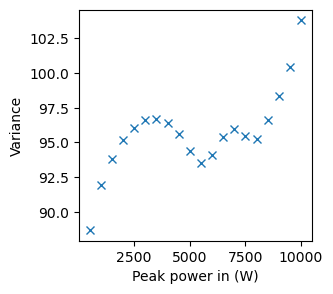

In [185]:
figure(figsize=(3,3))
plot(peak_power_list, 10log10.(fano_list .* n_out_list), "x")
xlabel("Peak power in (W)")
ylabel("Variance")
display(gcf())

In [188]:
## Little attenuation test.
atten = 0.1;
fano_list_with_loss = atten .* fano_list .+ (1 .- atten);

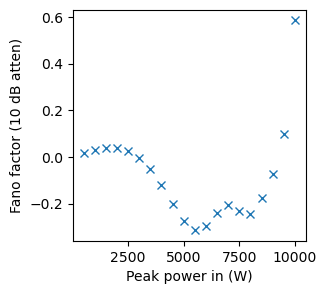

In [189]:
figure(figsize=(3,3))
plot(peak_power_list, 10log10.(fano_list_with_loss), "x")
xlabel("Peak power in (W)")
ylabel("Fano factor (10 dB atten)")
display(gcf())

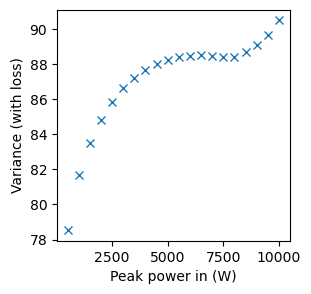

In [192]:
figure(figsize=(3,3))
plot(peak_power_list, 10log10.(fano_list_with_loss .* n_out_list * atten), "x")
xlabel("Peak power in (W)")
ylabel("Variance (with loss)")
display(gcf())

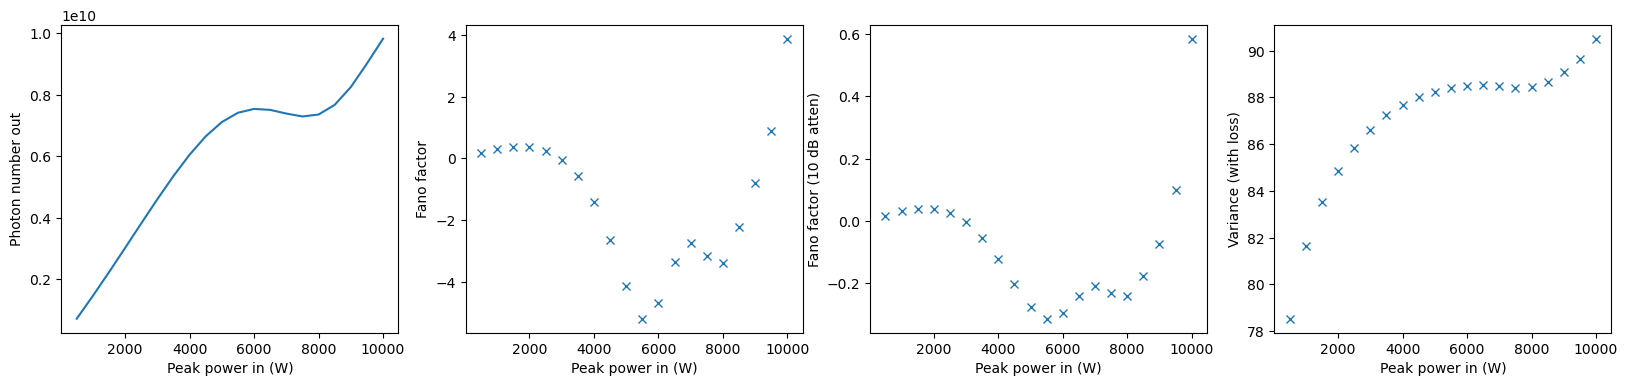

In [207]:
figure(figsize=(20,4))

subplot(1,4,1)
plot(peak_power_list, n_out_list,"-")
xlabel("Peak power in (W)")
ylabel("Photon number out")

subplot(1,4,2)
plot(peak_power_list, 10log10.(fano_list), "x")
xlabel("Peak power in (W)")
ylabel("Fano factor")

subplot(1,4,3)
plot(peak_power_list, 10log10.(fano_list_with_loss), "x")
xlabel("Peak power in (W)")
ylabel("Fano factor (10 dB atten)")

subplot(1,4,4)
plot(peak_power_list, 10log10.(fano_list_with_loss .* n_out_list * atten), "x")
xlabel("Peak power in (W)")
ylabel("Variance (with loss)")


display(gcf())

